<a href="https://colab.research.google.com/github/yewonhn/My-AI-Lab/blob/main/7%EC%A3%BC%EC%B0%A8/07_wine_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##파이토치(PyTorch)란?
딥러닝 모델을 설계하고 직접 코드로 만들어 학습시키기 위한 도구 중 하나 <br>
- 텐서(숫자 배열)를 다룸
- 신경망 만듬
- 자동으로 미분(그래디언트) 계산
- 모델 학습시킴

학습을 수월하게 하기 위하여
- train/test 분리 -> 과적합 방지
- 정규화 -> 학습 안정화
- tensor -> GPU/연산 최적화

파이토치는 딥러닝 모델을 구현하고 학습시키기 위한 도구이다.

이 실습을 통해 데이터 전처리, 모델 학습, 성능 평가의 과정을 학습할 수 있었다.  
특히 입력 데이터의 형태와 모델 구조가 얼마나 중요한지 확인할 수 있었다.

(batch, channel, length)의 모델이 요구하는 형태를 맞추기 위해서 unsqueeze, reshape를 하며 차원을 맞추었다.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
from torchsummary import summary
import numpy as np

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/wine.csv')
data

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [ ]:
data.columns

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='object')

In [ ]:
columns = ['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline']

In [ ]:
label_encoders = {}
for column in columns:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

In [ ]:
data

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,0,118,43,44,12,45,73,107,11,87,81,49,120,94
1,0,65,49,18,1,21,68,91,9,31,56,50,102,92
2,0,63,71,63,32,22,73,115,13,96,83,48,86,101
3,0,121,59,49,21,33,95,122,7,84,109,30,104,116
4,0,67,81,75,45,37,73,89,20,66,53,49,73,66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,2,92,131,46,42,16,23,12,30,22,108,10,22,67
174,2,76,113,48,51,23,30,19,24,40,104,16,10,68
175,2,68,119,29,40,39,17,17,24,35,125,6,10,74
176,2,64,81,38,40,39,22,16,31,45,120,7,14,75


###흐름
1. 데이터 전처리
2. train/test 분리
3. tensor 변환
4. 데이터 형태 맞추기
5. 모델 정의(CNN구조설계, layer구성)
6. 학습 설정(loss, optimizer)
7. 모델 학습 및 평가

In [ ]:
X = data.drop('Wine', axis=1).values
y = data['Wine'].values

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((142, 13), (36, 13), (142,), (36,))

In [ ]:
# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.int64)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.int64)

In [ ]:
# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([142, 13]),
 torch.Size([36, 13]),
 torch.Size([142]),
 torch.Size([36]))

구분 :	NumPy	PyTorch<br>
타입 :	tuple	torch.Size<br>
출력 :	(142, 13)	torch.Size([142, 13])<br>
의미 : 	동일

#모델 정의

In [ ]:
print(set(y))  #입력층 개수 확인

{np.int64(0), np.int64(1), np.int64(2)}


In [ ]:
class CarEvaluationDense(nn.Module):
    def __init__(self):
        super(CarEvaluationDense, self).__init__()
        self.fc1 = nn.Linear(13, 64) # 입력 feature 개수 :  13
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 3)  # 클래스 개수 = 출력 노드 수: [0,1,2] 총 3

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize the model, loss function, and optimizer
model = CarEvaluationDense()

#손실 함수 및 최적화 기법 정의

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#모델 학습

In [ ]:
# Variables to store loss and accuracy
train_losses = []
test_accuracies = []

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_dataloader:
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Calculate average loss over an epoch
    train_losses.append(running_loss / len(train_dataloader))

    # Evaluate on test data
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {train_losses[-1]:.4f}, Accuracy: {accuracy:.2f}%")

print("Training complete.")

Epoch 1/20, Loss: 1.0759, Accuracy: 44.44%
Epoch 2/20, Loss: 1.0096, Accuracy: 61.11%
Epoch 3/20, Loss: 0.9460, Accuracy: 86.11%
Epoch 4/20, Loss: 0.8828, Accuracy: 94.44%
Epoch 5/20, Loss: 0.8101, Accuracy: 94.44%
Epoch 6/20, Loss: 0.7292, Accuracy: 94.44%
Epoch 7/20, Loss: 0.6414, Accuracy: 94.44%
Epoch 8/20, Loss: 0.5688, Accuracy: 97.22%
Epoch 9/20, Loss: 0.4838, Accuracy: 97.22%
Epoch 10/20, Loss: 0.4244, Accuracy: 97.22%
Epoch 11/20, Loss: 0.3316, Accuracy: 97.22%
Epoch 12/20, Loss: 0.2744, Accuracy: 97.22%
Epoch 13/20, Loss: 0.2302, Accuracy: 97.22%
Epoch 14/20, Loss: 0.1992, Accuracy: 97.22%
Epoch 15/20, Loss: 0.1721, Accuracy: 100.00%
Epoch 16/20, Loss: 0.1323, Accuracy: 100.00%
Epoch 17/20, Loss: 0.1281, Accuracy: 100.00%
Epoch 18/20, Loss: 0.1025, Accuracy: 100.00%
Epoch 19/20, Loss: 0.0853, Accuracy: 100.00%
Epoch 20/20, Loss: 0.0904, Accuracy: 100.00%
Training complete.


#모델 평가

In [ ]:
# Evaluation
model.eval()
all_labels = []
all_predictions = []
with torch.no_grad():
    for inputs, labels in test_dataloader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# Calculate metrics
conf_matrix = confusion_matrix(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions, average='weighted')
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')

# Calculate specificity for each class
specificity = []
for i in range(conf_matrix.shape[0]):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    specificity.append(tn / (tn + fp))

print(f'Confusion Matrix:\n{conf_matrix}')
print(f'F1 Score: {f1:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'Specificity: {np.mean(specificity):.2f}')

Confusion Matrix:
[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]
F1 Score: 1.00
Precision: 1.00
Recall: 1.00
Specificity: 1.00


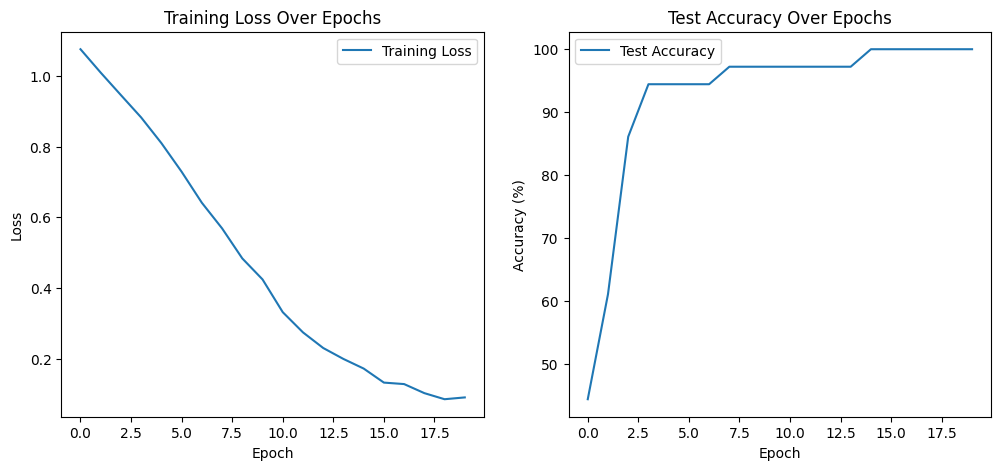

In [ ]:
# Plot the loss and accuracy
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Over Epochs')
plt.legend()

plt.show()


In [ ]:
# 데이터와 타겟 분리
X = data.drop('Wine', axis=1).values
y = data['Wine'].values

In [ ]:
# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
data_array = np.hstack((X, y.reshape(-1, 1)))

In [ ]:
data_array.shape

(178, 14)

In [ ]:
# 시퀀스 함수 나누기
def split_sequences(sequences, n_steps):
    X, y = list(), list()
    for i in range(len(sequences)):
        end_ix = i + n_steps
        if end_ix > len(sequences):
            break
        seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix-1, -1]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

# 시퀀스(순서 데이터)에 변환을 적용
n_steps = 5
X, y = split_sequences(data_array, n_steps)

# 데이터를 학습용과 테스트로 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape,

((139, 5, 13), (139,), (35, 5, 13), (35,))

In [ ]:
# 파이토치 텐서로 변환
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.int64)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.int64)

# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
import torch.nn as nn

# 1차원 CNN모델 정의
class CarEvaluationCNN(nn.Module):
    def __init__(self):
        super(CarEvaluationCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)  # Change input channels to 6
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 13, 64)  # Adjust the linear layer input size accordingly
        self.fc2 = nn.Linear(64, 3)  # 4 classes in the dataset

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
# 신경망 구조 생성
model = CarEvaluationCNN()

In [ ]:
from torchsummary import summary

# 모델 구조를 요약해서 보여줌
summary(model, input_size=(1, 13))   # 이 숫자도 모델에 맞게

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1               [-1, 16, 13]              64
            Conv1d-2               [-1, 32, 13]           1,568
            Linear-3                   [-1, 64]          26,688
            Linear-4                    [-1, 3]             195
Total params: 28,515
Trainable params: 28,515
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.11
Estimated Total Size (MB): 0.11
----------------------------------------------------------------


In [ ]:
criterion = nn.CrossEntropyLoss()  # 예측이 얼마나 틀렸는지
optimizer = optim.Adam(model.parameters(), lr=0.001)  # 모델을 어떻게 업데이트 할지

# Variables to store loss and accuracy
train_losses = []
test_accuracies = []

In [ ]:
print(inputs.shape)

torch.Size([32, 1, 5, 13])


In [ ]:
inputs = inputs.squeeze(1)   # (32, 5, 13)
inputs = inputs[:, 0, :]     # (32, 13)
inputs = inputs.unsqueeze(1) # (32, 1, 13)

In [ ]:
print(inputs.shape)

torch.Size([32, 1, 13])


In [ ]:
# Training loop
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_dataloader:
        optimizer.zero_grad()

        inputs = inputs.squeeze(1)
        inputs = inputs[:, 0, :]
        inputs = inputs.unsqueeze(1)

        # 입력 그대로 사용 (unsqueeze / permute 없음)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_dataloader))

    # Evaluation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_dataloader:

            inputs = inputs.squeeze(1)
            inputs = inputs[:, 0, :]
            inputs = inputs.unsqueeze(1)

            # 여기도 그대로
            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_losses[-1]:.4f}, Accuracy: {accuracy:.2f}%")

print("Training complete.")

Epoch 1/20, Loss: 1.0725, Accuracy: 68.57%
Epoch 2/20, Loss: 0.9704, Accuracy: 91.43%
Epoch 3/20, Loss: 0.8239, Accuracy: 91.43%
Epoch 4/20, Loss: 0.6502, Accuracy: 88.57%
Epoch 5/20, Loss: 0.4931, Accuracy: 91.43%
Epoch 6/20, Loss: 0.3432, Accuracy: 94.29%
Epoch 7/20, Loss: 0.2711, Accuracy: 94.29%
Epoch 8/20, Loss: 0.2283, Accuracy: 94.29%
Epoch 9/20, Loss: 0.2108, Accuracy: 91.43%
Epoch 10/20, Loss: 0.1884, Accuracy: 91.43%
Epoch 11/20, Loss: 0.1745, Accuracy: 94.29%
Epoch 12/20, Loss: 0.1956, Accuracy: 94.29%
Epoch 13/20, Loss: 0.1741, Accuracy: 94.29%
Epoch 14/20, Loss: 0.1479, Accuracy: 94.29%
Epoch 15/20, Loss: 0.1583, Accuracy: 91.43%
Epoch 16/20, Loss: 0.1381, Accuracy: 91.43%
Epoch 17/20, Loss: 0.1361, Accuracy: 94.29%
Epoch 18/20, Loss: 0.1353, Accuracy: 94.29%
Epoch 19/20, Loss: 0.1122, Accuracy: 91.43%
Epoch 20/20, Loss: 0.1093, Accuracy: 94.29%
Training complete.


Confusion Matrix:
[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]
F1 Score: 1.00
Precision: 1.00
Recall: 1.00
Specificity: 1.00


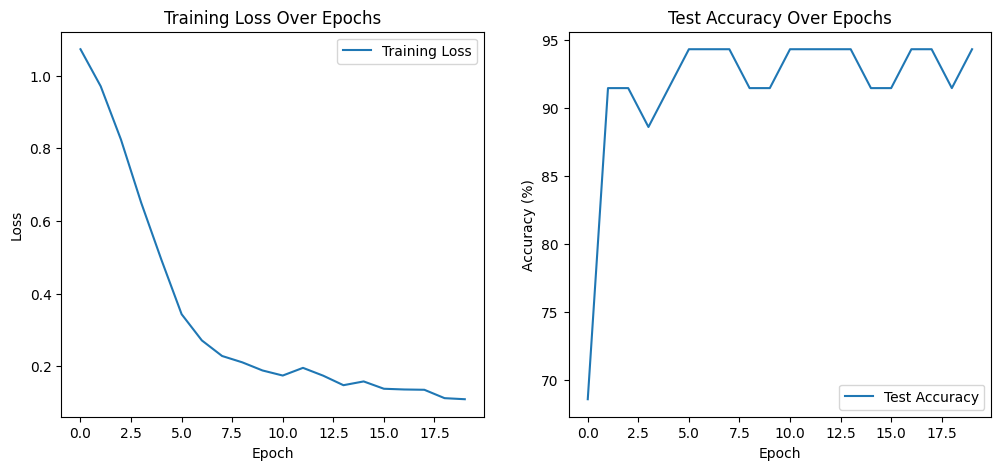

In [ ]:
# 넘파이 배열로 변환     이유 : sklearn함수들이numpy를 더 잘 처리한대
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# 성능에 대한 평가 지표 계
conf_matrix = confusion_matrix(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions, average='weighted')   # 실제값과 예측값을 비
precision = precision_score(all_labels, all_predictions, average='weighted')  # 맞다고 한 것 중에 진짜 맞은 비
recall = recall_score(all_labels, all_predictions, average='weighted')  # 실제 정답 중 얼마나 맞추었는

# 각 클래스별 특이도 계산
specificity = []
for i in range(conf_matrix.shape[0]):
    # True Negative (정답도 아니고 예측도 아닌 것)
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    # False Positive (틀리게 맞췄다고 한 것)
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    specificity.append(tn / (tn + fp))


# 모델의 학습 과정은 plot으로 확인하고, 최종 성능은 metrics로 평가


# 평가 지표 출력
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'F1 Score: {f1:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'Specificity: {np.mean(specificity):.2f}')

# 손실과 정확도 그래프를 그린다
plt.figure(figsize=(12, 5))

# 학습 손실 변화
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# 테스트 정확도 변
plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Over Epochs')
plt.legend()